In [5]:
cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/"

/storage/project/r-js130-0/pagrawala6/clone_thesisplots


A - O: min = -3265.208330 cm^-1, max = 426.624825 cm^-1, max absolute = 3265.208330 cm^-1
B - O: min = -3006.991464 cm^-1, max = 294.486679 cm^-1, max absolute = 3006.991464 cm^-1
C - O: min = -3006.991464 cm^-1, max = 294.486679 cm^-1, max absolute = 3006.991464 cm^-1
D - O: min = -3006.991464 cm^-1, max = 294.486679 cm^-1, max absolute = 3006.991464 cm^-1
E - O: min = -3006.991464 cm^-1, max = 294.486679 cm^-1, max absolute = 3006.991464 cm^-1


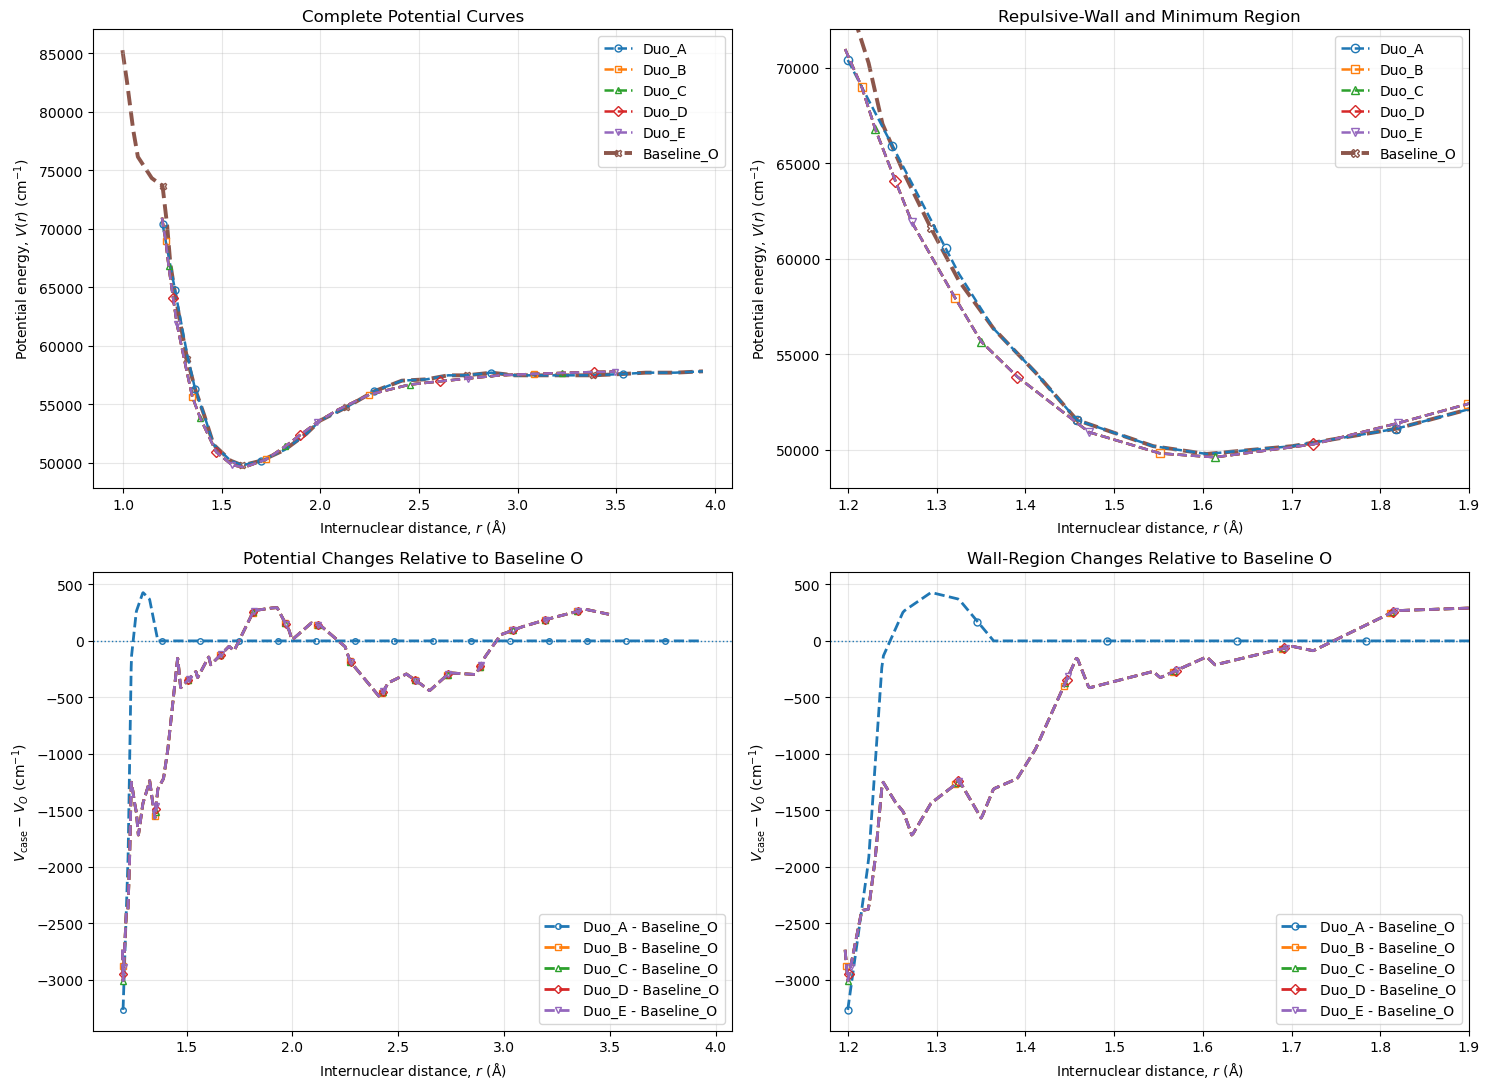

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def read_potential_curves(filename="all_pots.xlsx"):
    """
    Read paired columns from the spreadsheet:

        A-B   -> case A
        C-D   -> case B
        E-F   -> case C
        G-H   -> case D
        I-J   -> case E
        K-L   -> baseline case O

    The case label is taken from the first row of each potential-energy
    column: B1, D1, F1, H1, J1, L1, ...
    """
    raw = pd.read_excel(filename, header=None)

    curves = {}

    number_of_pairs = raw.shape[1] // 2

    for pair_index in range(number_of_pairs):
        r_column = 2 * pair_index
        potential_column = r_column + 1

        case = raw.iloc[0, potential_column]

        if pd.isna(case):
            continue

        case = str(case).strip()

        r = pd.to_numeric(
            raw.iloc[1:, r_column],
            errors="coerce"
        ).to_numpy()

        potential = pd.to_numeric(
            raw.iloc[1:, potential_column],
            errors="coerce"
        ).to_numpy()

        valid = np.isfinite(r) & np.isfinite(potential)

        r = r[valid]
        potential = potential[valid]

        order = np.argsort(r)

        curves[case] = {
            "r": r[order],
            "potential": potential[order]
        }

    return curves


def interpolate_difference(
    curves,
    case,
    baseline_case="O",
    number_of_points=1500
):
    """
    Interpolate two curves onto a common r grid and calculate

        V_case(r) - V_baseline(r)
    """
    r_case = curves[case]["r"]
    v_case = curves[case]["potential"]

    r_baseline = curves[baseline_case]["r"]
    v_baseline = curves[baseline_case]["potential"]

    common_r_min = max(r_case.min(), r_baseline.min())
    common_r_max = min(r_case.max(), r_baseline.max())

    common_r = np.linspace(
        common_r_min,
        common_r_max,
        number_of_points
    )

    v_case_interpolated = np.interp(
        common_r,
        r_case,
        v_case
    )

    v_baseline_interpolated = np.interp(
        common_r,
        r_baseline,
        v_baseline
    )

    difference = (
        v_case_interpolated
        - v_baseline_interpolated
    )

    return common_r, difference


def plot_potential_curves(filename="all_pots.xlsx"):
    curves = read_potential_curves(filename)

    baseline_case = "O"

    if baseline_case not in curves:
        raise ValueError(
            "Baseline case O was not found. Ensure O is written in the "
            "first row of its potential-energy column."
        )

    case_ids = list(curves.keys())

    comparison_cases = [
        case for case in case_ids
        if case != baseline_case
    ]

    case_labels = {
        case: (
            "Baseline_O"
            if case == baseline_case
            else f"Duo_{case}"
        )
        for case in case_ids
    }

    markers = {
        "A": "o",
        "B": "s",
        "C": "^",
        "D": "D",
        "E": "v",
        "O": "X"
    }

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 11)
    )

    ax_full = axes[0, 0]
    ax_wall = axes[0, 1]
    ax_difference = axes[1, 0]
    ax_difference_zoom = axes[1, 1]

    # ---------------------------------------------------------
    # 1. Full potential curves
    # ---------------------------------------------------------
    for index, case in enumerate(case_ids):
        r = curves[case]["r"]
        potential = curves[case]["potential"]

        linewidth = 2.8 if case == baseline_case else 1.8
        zorder = 1 if case == baseline_case else 2

        ax_full.plot(
            r,
            potential,
            linestyle="--",
            linewidth=linewidth,
            marker=markers.get(case, "o"),
            markersize=5,
            markerfacecolor="none",
            markevery=(index, 5),
            label=case_labels[case],
            zorder=zorder
        )

    ax_full.set_xlabel(
        r"Internuclear distance, $r$ ($\mathrm{\AA}$)"
    )
    ax_full.set_ylabel(
        r"Potential energy, $V(r)$ ($\mathrm{cm}^{-1}$)"
    )
    ax_full.set_title("Complete Potential Curves")
    ax_full.grid(True, alpha=0.3)
    ax_full.legend()

    # ---------------------------------------------------------
    # 2. Repulsive-wall and minimum-region zoom
    # ---------------------------------------------------------
    for index, case in enumerate(case_ids):
        r = curves[case]["r"]
        potential = curves[case]["potential"]

        linewidth = 2.8 if case == baseline_case else 1.8
        zorder = 1 if case == baseline_case else 2

        ax_wall.plot(
            r,
            potential,
            linestyle="--",
            linewidth=linewidth,
            marker=markers.get(case, "o"),
            markersize=6,
            markerfacecolor="none",
            markevery=(index, 4),
            label=case_labels[case],
            zorder=zorder
        )

    ax_wall.set_xlim(1.18, 1.90)
    ax_wall.set_ylim(48000, 72000)

    ax_wall.set_xlabel(
        r"Internuclear distance, $r$ ($\mathrm{\AA}$)"
    )
    ax_wall.set_ylabel(
        r"Potential energy, $V(r)$ ($\mathrm{cm}^{-1}$)"
    )
    ax_wall.set_title("Repulsive-Wall and Minimum Region")
    ax_wall.grid(True, alpha=0.3)
    ax_wall.legend()

    # ---------------------------------------------------------
    # 3. Differences relative to baseline O
    # ---------------------------------------------------------
    differences = {}

    for index, case in enumerate(comparison_cases):
        common_r, difference = interpolate_difference(
            curves,
            case,
            baseline_case=baseline_case
        )

        differences[case] = {
            "r": common_r,
            "difference": difference
        }

        ax_difference.plot(
            common_r,
            difference,
            linestyle="--",
            linewidth=2,
            marker=markers.get(case, "o"),
            markersize=4,
            markerfacecolor="none",
            markevery=(index, 100),
            label=fr"{case_labels[case]} - Baseline_O"
        )

        print(
            f"{case} - O:"
            f" min = {difference.min():.6f} cm^-1,"
            f" max = {difference.max():.6f} cm^-1,"
            f" max absolute = {np.max(np.abs(difference)):.6f} cm^-1"
        )

    ax_difference.axhline(
        0.0,
        linestyle=":",
        linewidth=1
    )

    ax_difference.set_xlabel(
        r"Internuclear distance, $r$ ($\mathrm{\AA}$)"
    )
    ax_difference.set_ylabel(
        r"$V_{\mathrm{case}}-V_O$ ($\mathrm{cm}^{-1}$)"
    )
    ax_difference.set_title("Potential Changes Relative to Baseline O")
    ax_difference.grid(True, alpha=0.3)
    ax_difference.legend()

    # ---------------------------------------------------------
    # 4. Zoomed differences in the wall region
    # ---------------------------------------------------------
    for index, case in enumerate(comparison_cases):
        common_r = differences[case]["r"]
        difference = differences[case]["difference"]

        ax_difference_zoom.plot(
            common_r,
            difference,
            linestyle="--",
            linewidth=2,
            marker=markers.get(case, "o"),
            markersize=5,
            markerfacecolor="none",
            markevery=(index, 80),
            label=fr"{case_labels[case]} - Baseline_O"
        )

    ax_difference_zoom.axhline(
        0.0,
        linestyle=":",
        linewidth=1
    )

    ax_difference_zoom.set_xlim(1.18, 1.90)

    ax_difference_zoom.set_xlabel(
        r"Internuclear distance, $r$ ($\mathrm{\AA}$)"
    )
    ax_difference_zoom.set_ylabel(
        r"$V_{\mathrm{case}}-V_O$ ($\mathrm{cm}^{-1}$)"
    )
    ax_difference_zoom.set_title(
        "Wall-Region Changes Relative to Baseline O"
    )
    ax_difference_zoom.grid(True, alpha=0.3)
    ax_difference_zoom.legend()

    plt.tight_layout()

    plt.savefig(
        "all_pots_comparison_with_baseline_O.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


if __name__ == "__main__":
    plot_potential_curves("all_pots.xlsx")